# Download and visualize ECMWF subseasonal forecast
If you do not have an ECMWF account, please make one here: https://accounts.ecmwf.int/auth/realms/ecmwf/login-actions/registration?client_id=cms-www&tab_id=Y_zocKf4JYs

Then head to this link to get the key that is necessary for the download: https://api.ecmwf.int/v1/key/

Make sure to have a working environment, see requirements .tx for necessary packages

Developed by Alexander Jong, feel free to email alec.jong@live.nl if you have any questions or suggestions.

### Define area of interest, import the necessary packages & functions

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import get_ECMWF_functions as gef
from IPython.display import display
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# # # namibia botswana
# lat1=-15
# lat2=-29.5
# lon1=11
# lon2=29

#Kenya
lat1=8
lat2=-8
lon1=30
lon2=45

#transfer lat lon to functions
gef.lat1=lat1
gef.lat2=lat2
gef.lon1=lon1
gef.lon2=lon2

## This is where you tell the ECWMF server who you are, so add your key and email to the api_config dictionary

In [3]:
# Define your API key content
api_config = {
    "url": "https://api.ecmwf.int/v1",
    "key": "f7cf0b931df86368ba8a27efce865439",  # Replace with your actual API key
    "email": "uruja@student.kit.edu"   # Replace with your email
}

gef.link_ECMWF_key(api_config)

API key file saved at: C:\Users\alecj\Bureaublad\ECMWF-S2S4AFRICA\Notebook\ecmwf_api_key.json
ECMWF_API_RC_FILE is set to: C:\Users\alecj\Bureaublad\ECMWF-S2S4AFRICA\Notebook\ecmwf_api_key.json


## Run the cell bellow to get the selection buttons.
Here you can select the start date of the forcast, which variables you want, which ensemble members you want (or ensemble mean) and how far into the future you want to get the forcast

In [4]:
from forecast_ui import build_forecast_ui

gui, ui_layout = build_forecast_ui()
display(ui_layout)

## After having selected what you want, define a filename and run the cell to donwload

In [9]:
filename='forecast'
gef.get_ECMWF(gui,filename)

AttributeError: module 'get_ECMWF_functions' has no attribute 'get_ECWMF'

### Open all files and agregate them to daily and weekly data for the chosen variables
enter the name of the file you want to open, this can also be a previously dowloaded file

In [3]:
filename='test'

daily_all_vars,weekly_all_vars,hourly_ds,temp_ds=gef.open_allfiles_and_compute_weekly(filename)

🎉 All files opened and Agregated


## plotting

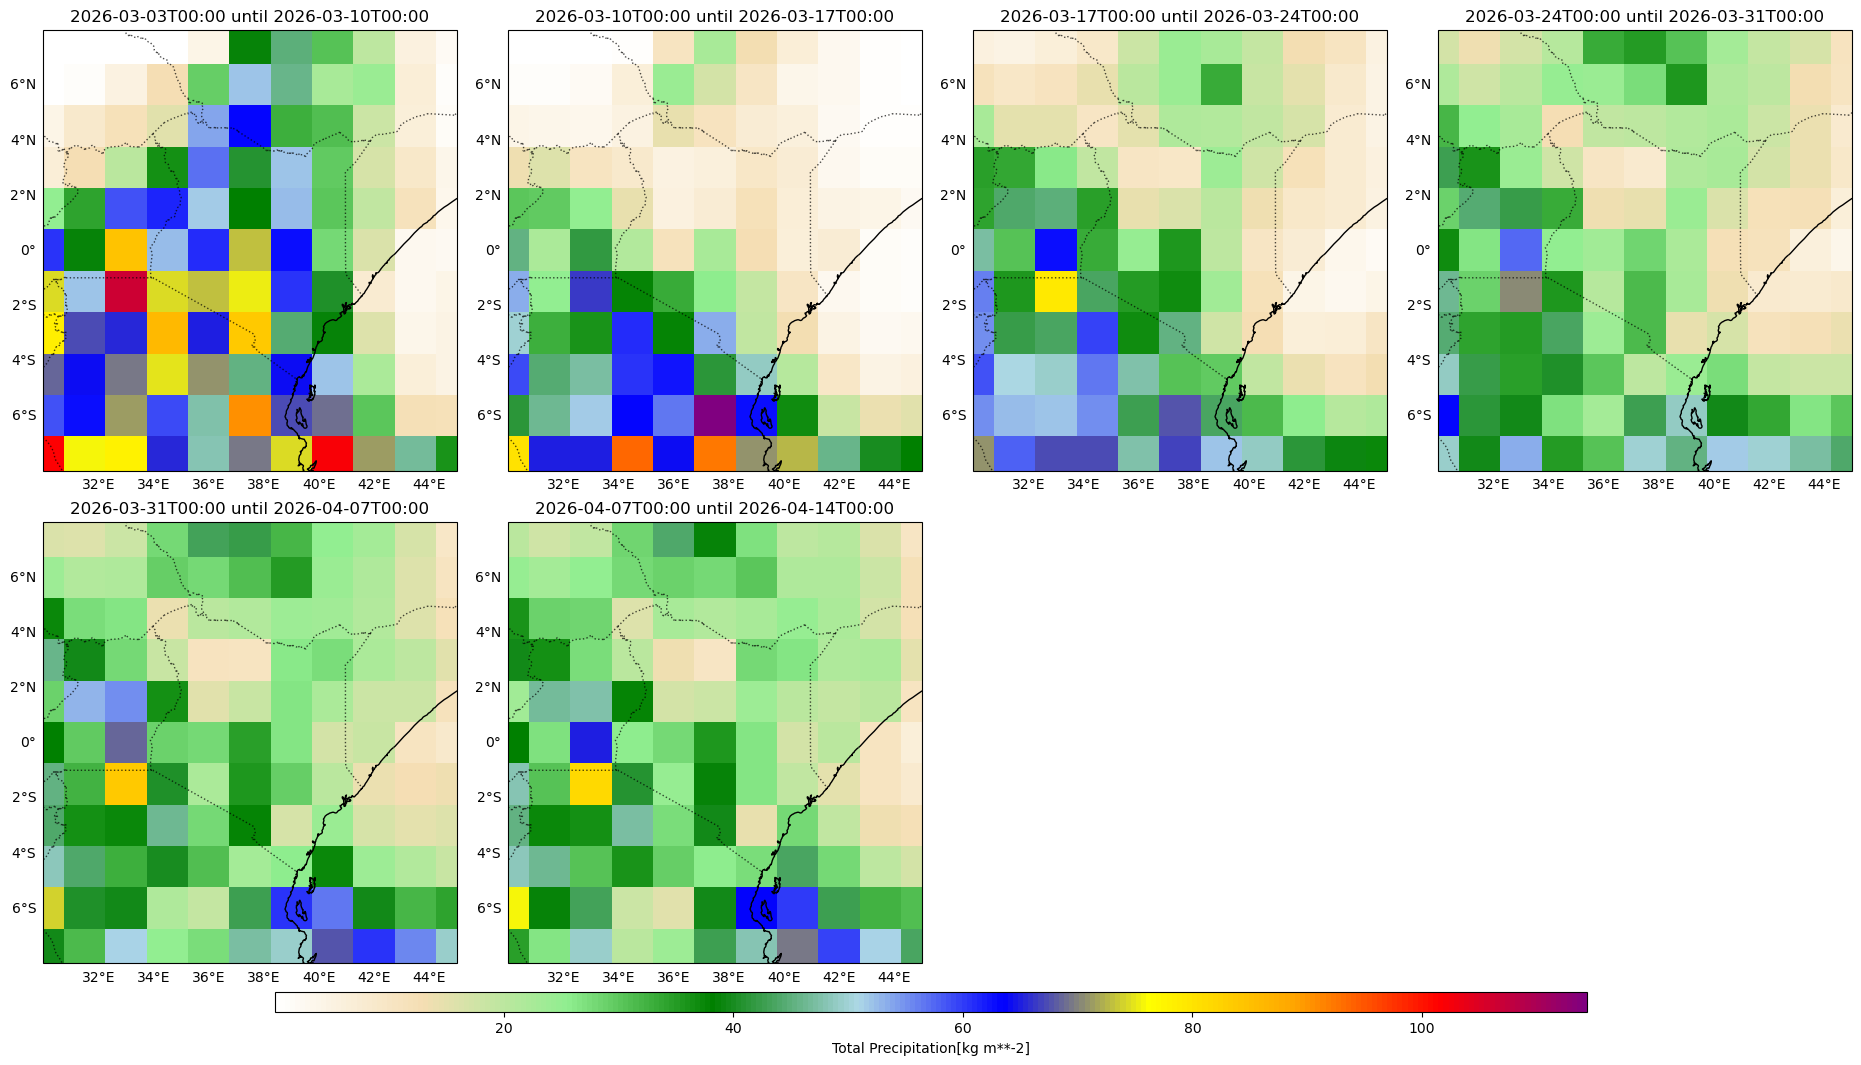

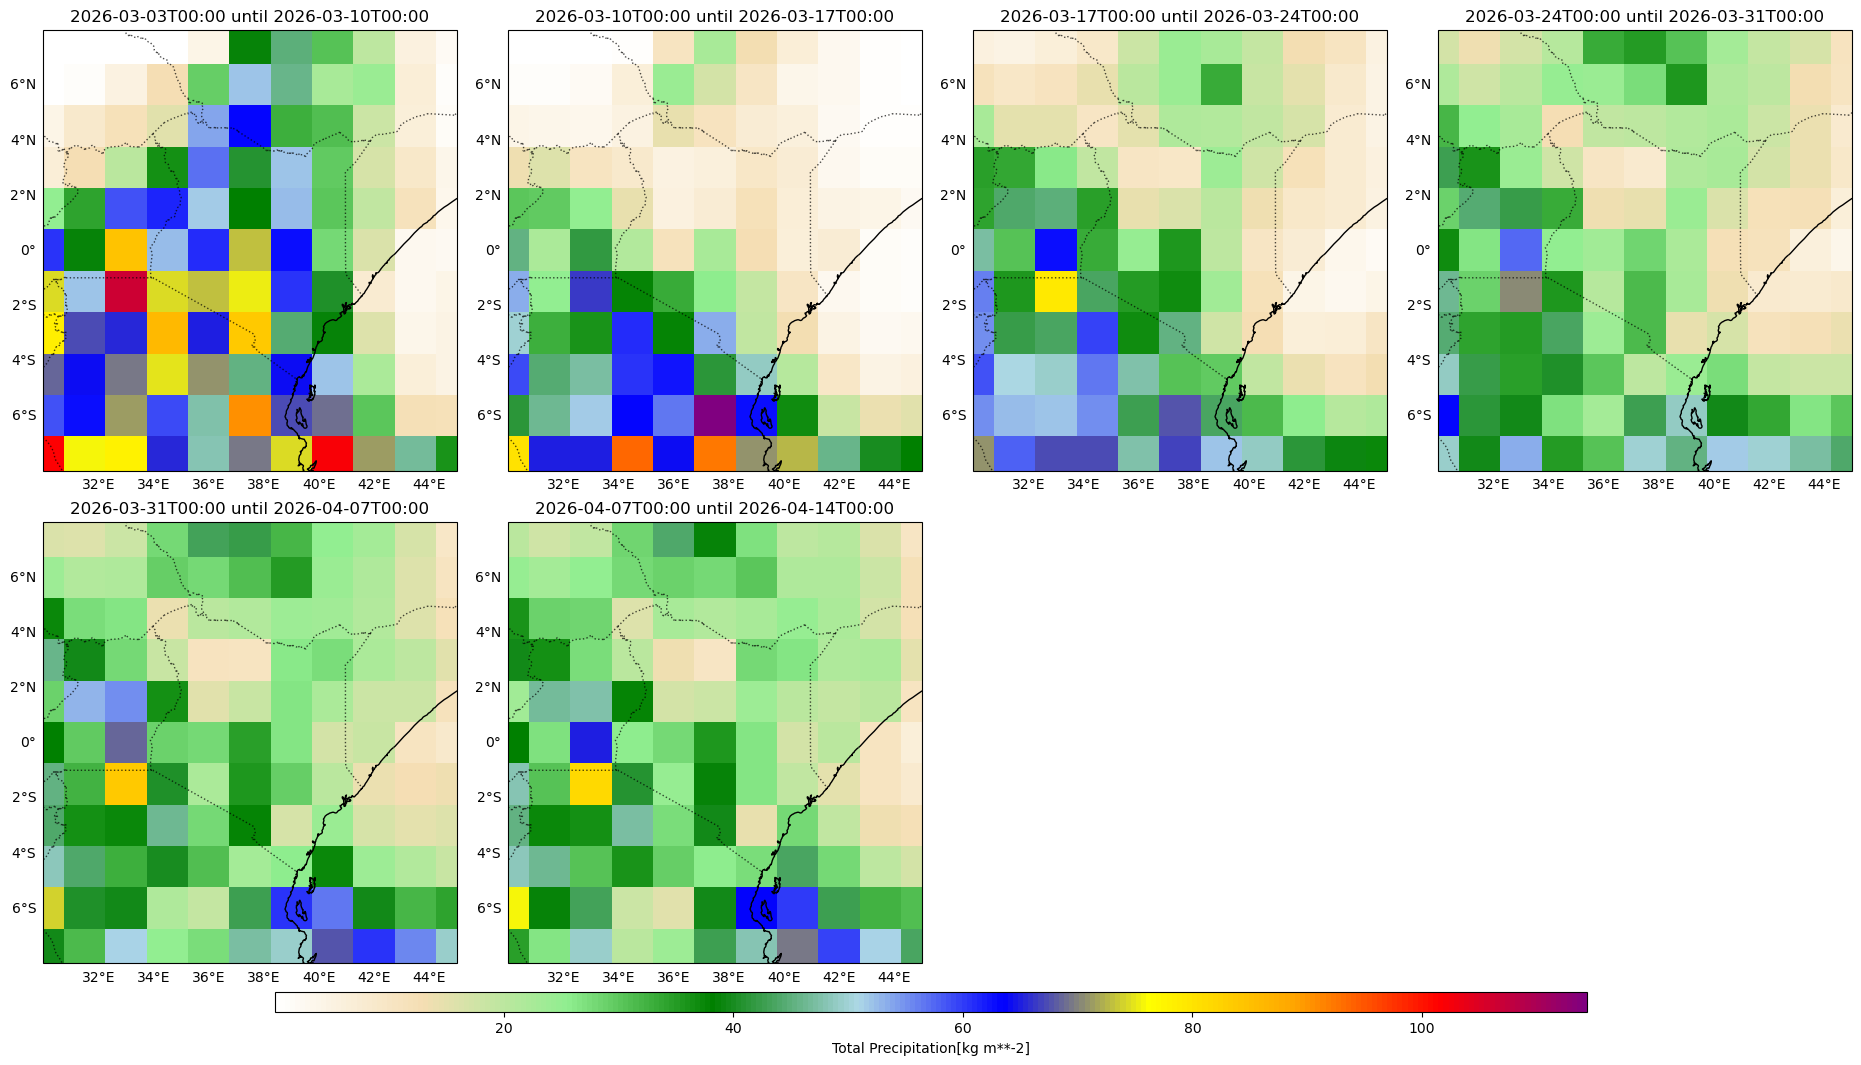

In [8]:
ds_to_plot=weekly_all_vars
gef.panel_plot_variable(ds_to_plot,variable='tp',forecast_timestep=ds_to_plot.step.values,cmap=gef.cmap)
# gef.panel_plot_variable(ds_to_plot,variable='t2m',forecast_timestep=ds_to_plot.step.values,cmap='rainbow')
# gef.panel_plot_variable(ds_to_plot,variable='msl',forecast_timestep=ds_to_plot.step.values,cmap='gist_rainbow_r')

## plot with contour of another variable

In [4]:
ds_to_plot=weekly_all_vars
gef.panel_plot_variable(ds_to_plot,variable='t2m',forecast_timestep=ds_to_plot.step.values,cmap='rainbow',add_contour=weekly_all_vars['tp'],contourcmap='Blues')

KeyError: "No variable named 't2m'. Variables on the dataset include ['tp', 'time', 'latitude', 'step', 'valid_time', 'longitude']"

## plot the change in a variable

C:\Users\alecj\Bureaublad\ECMWF-S2S4AFRICA\get_ECMWF_functions.py:354: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_diff=xr.concat(ds_list,dim='step')


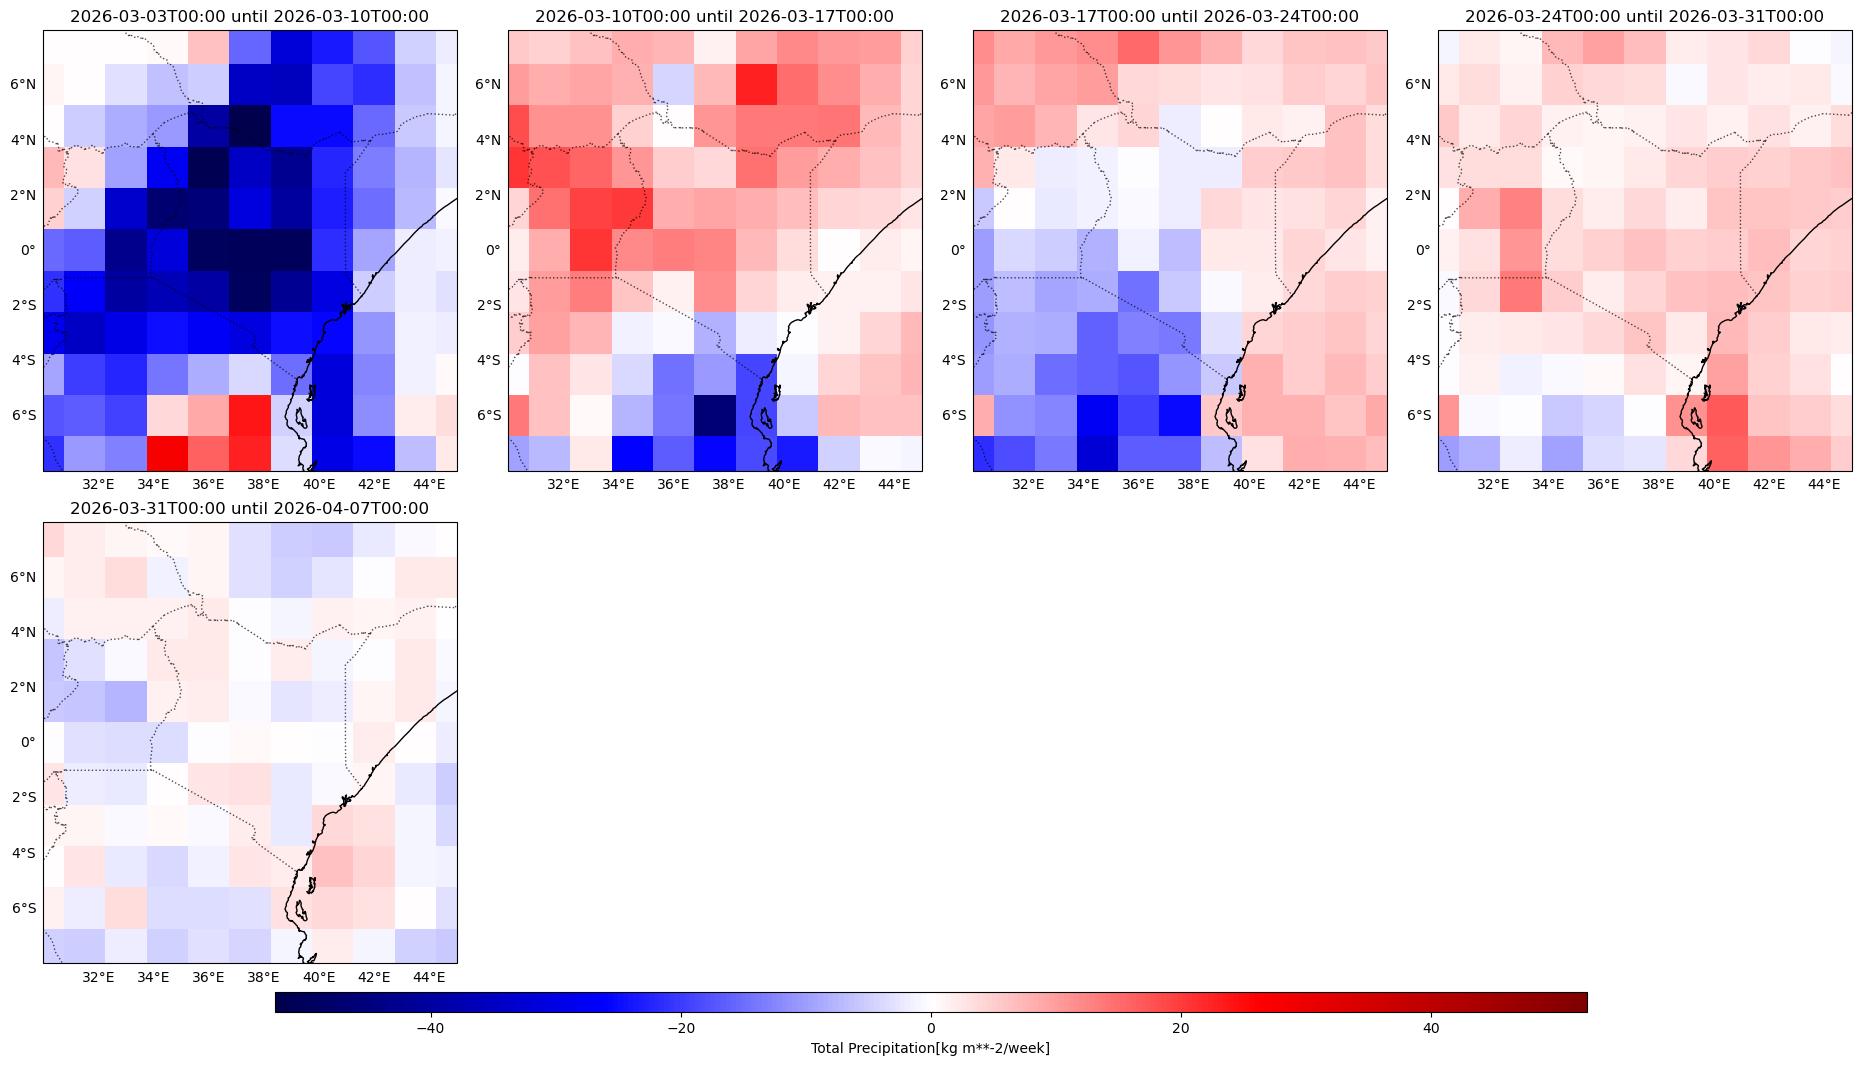

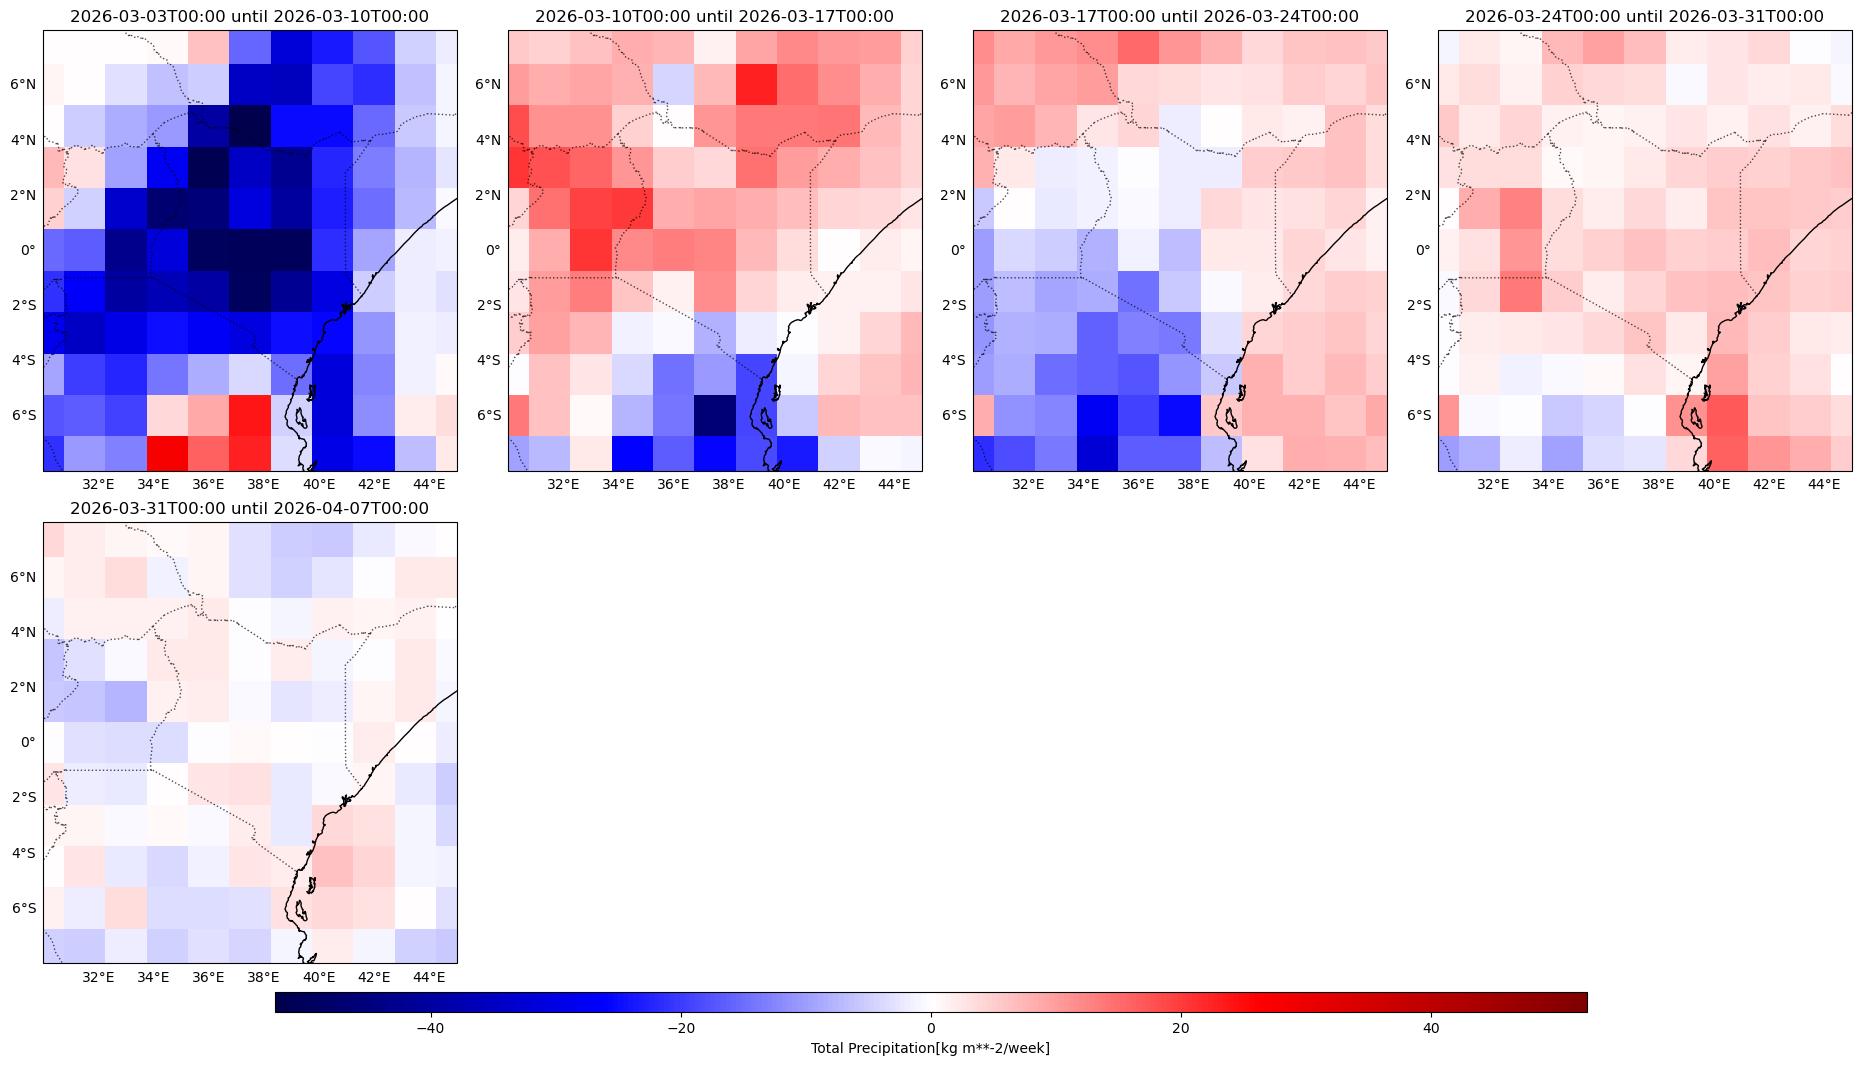

In [5]:
fontsize=16
ds_to_plot=weekly_all_vars
gef.panel_plot_variable(ds_to_plot,variable='tp',forecast_timestep=ds_to_plot.step.values,cmap='seismic',change=True)

## Plot chance to exceed a certain condition

only works, if you download the ensemble members

possible conditions:

'greater', 'smaller', 'equal', 'not equal', 'greater or equal', 'smaller or equal'

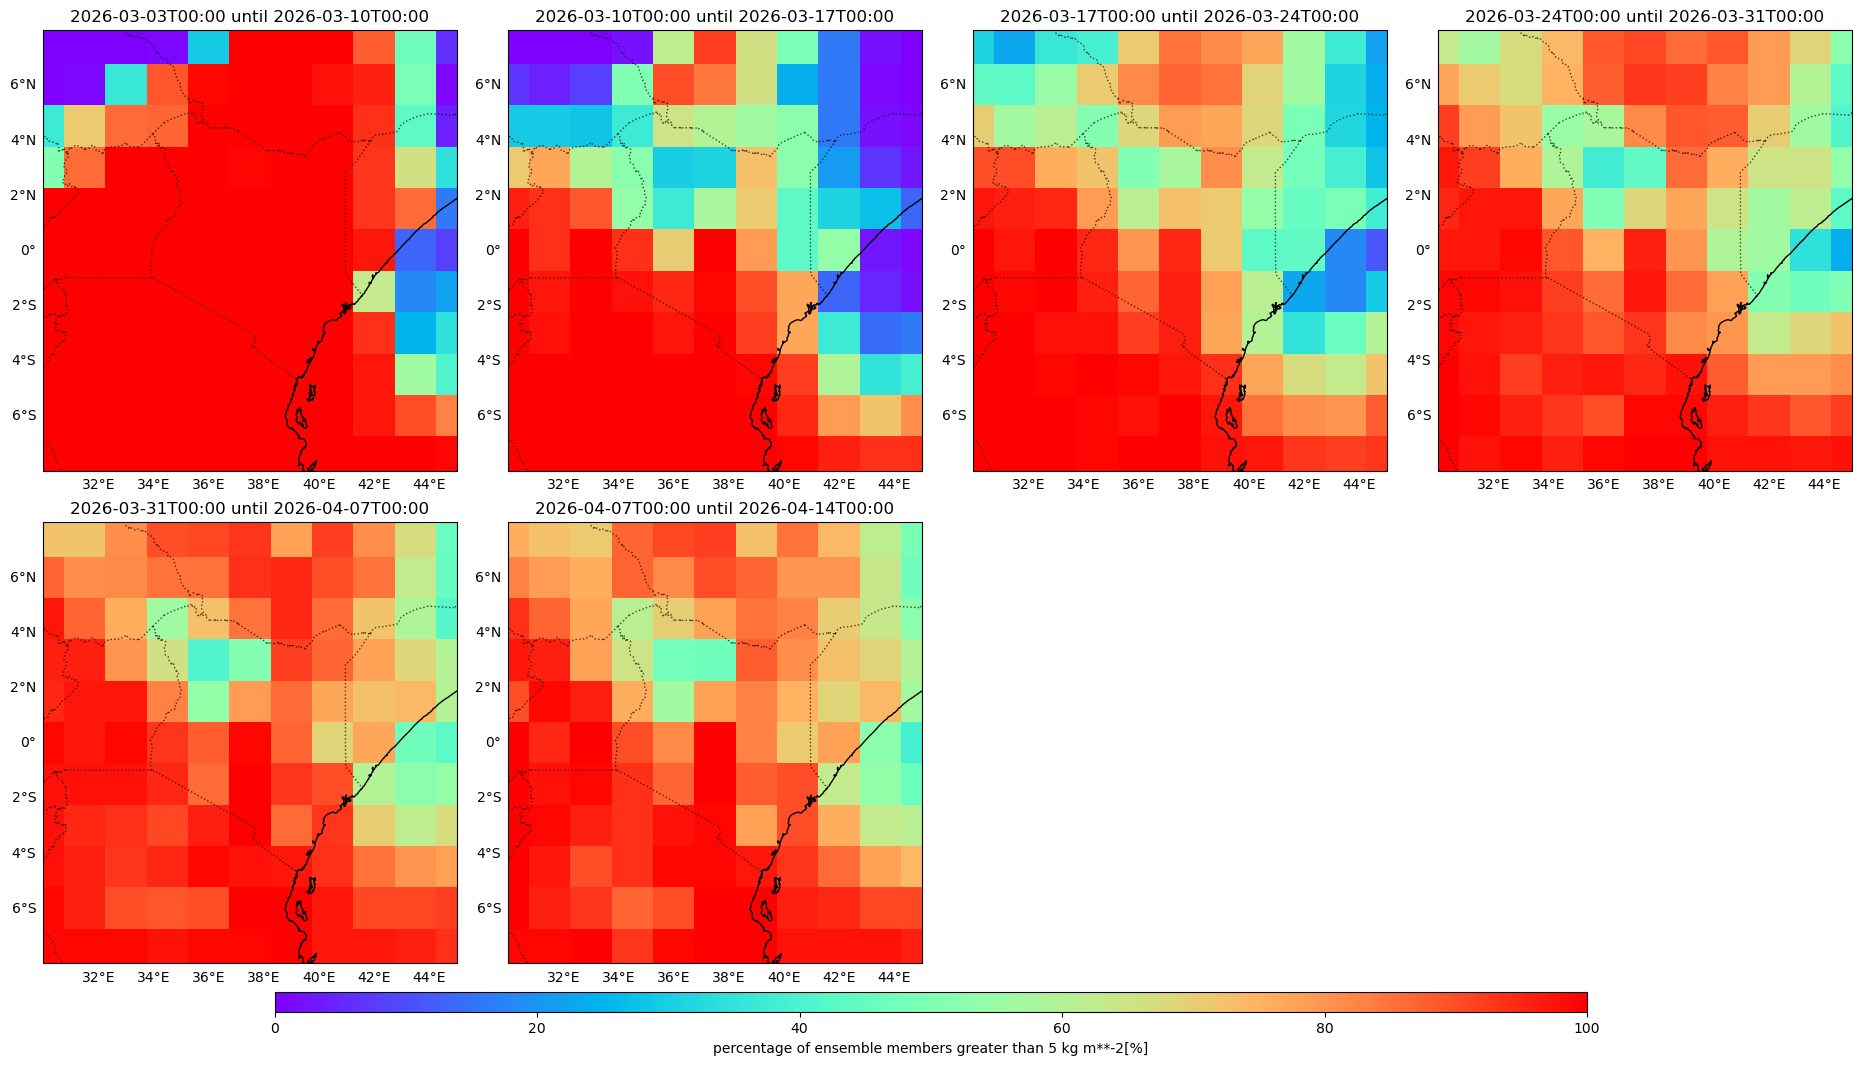

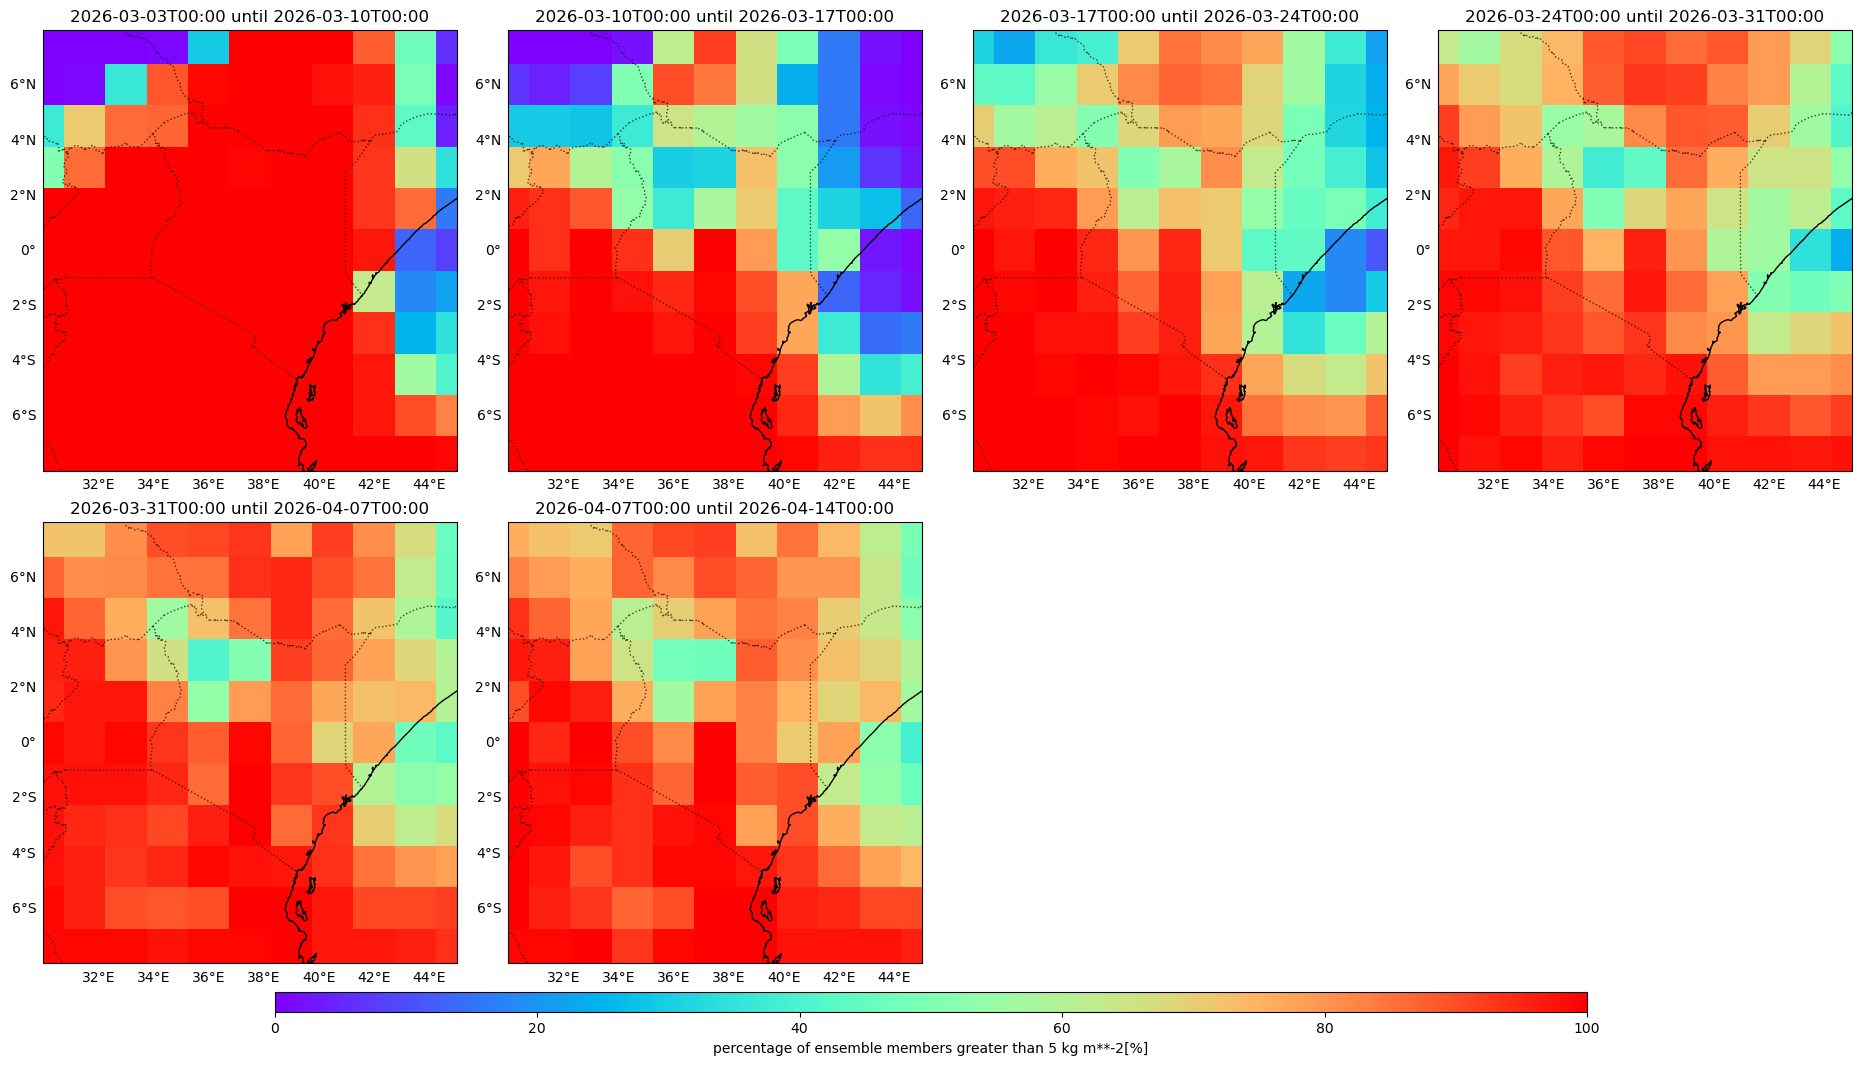

In [12]:
var='tp'
exceedance_percentage=gef.get_exceedance_percentage(weekly_all_vars,var,5,comparison='greater')
gef.panel_plot_variable(exceedance_percentage,var,exceedance_percentage.step.values,cmap='rainbow')

## Spagetti plot

only works, if you download the ensemble members

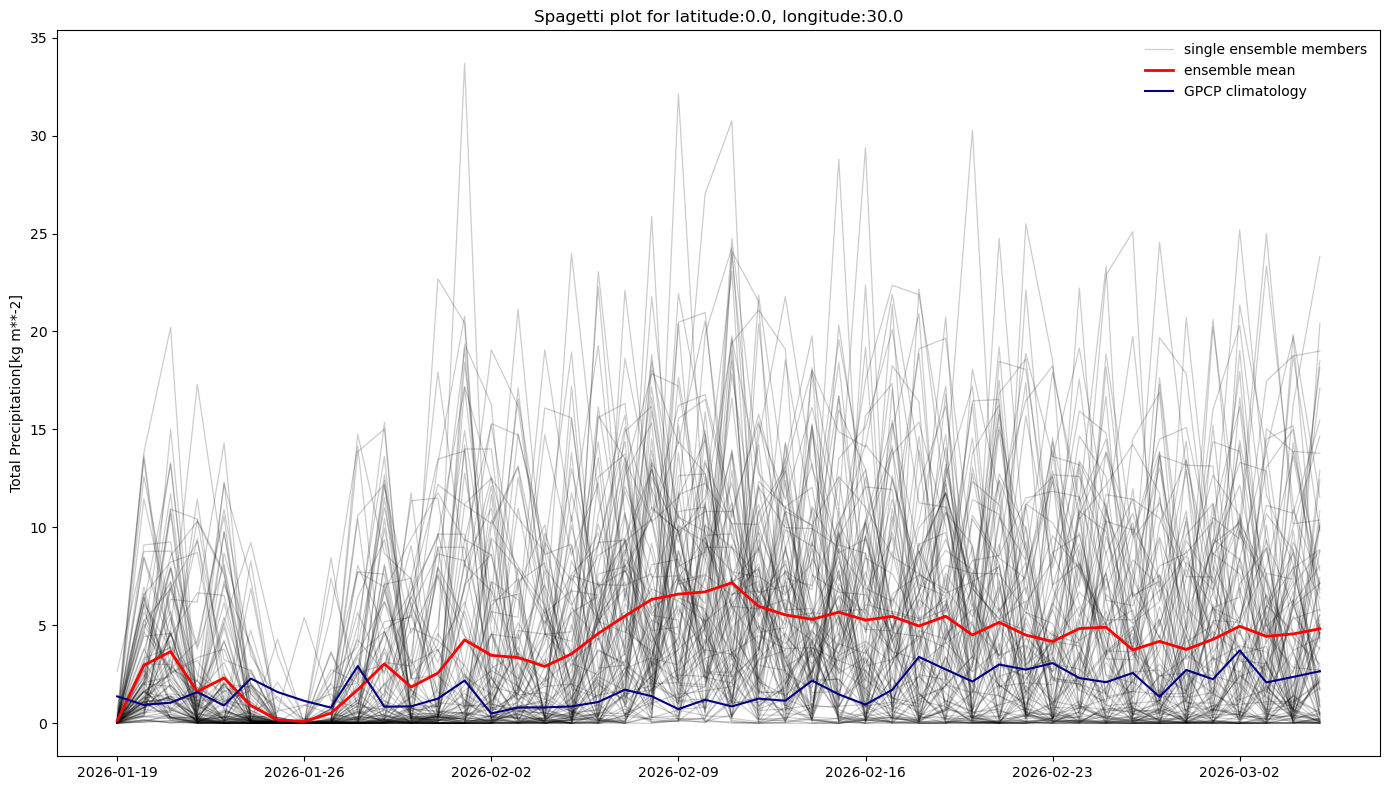

In [25]:
gef.spagetti_plot(daily_all_vars,'tp',lat=0,lon=30)

## Load the model climatology

In [5]:
### find the file that is closest in day to the starting day of the run
m_climate=gef.open_mclimate(daily_all_vars)

Model climatology starting on: 2025-01-17


## take a look at the model climatology

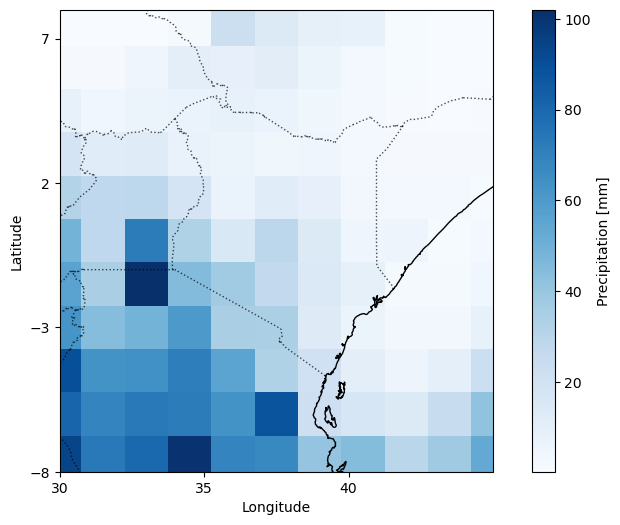

In [10]:
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
data=m_climate.isel(time=0).isel(quantile=90).sel(longitude=slice(lon1,lon2),latitude=slice(lat1,lat2))
cmap='Blues'
contour=ax.pcolormesh(data.longitude, data.latitude,data.tp, cmap=cmap)
ax.set_extent([lon1, lon2, lat2, lat1], crs=ccrs.PlateCarree())
# Add natural features for context (e.g., coastlines, borders)
ax.add_feature(cfeature.COASTLINE, edgecolor='black')
ax.add_feature(cfeature.BORDERS, linestyle=':',alpha=0.7)
    
# Set tick marks for the longitude and latitude axes
ax.set_xticks(range(int(lon1), int(lon2), 5))  # Longitude ticks from 10 to 25
ax.set_yticks(range(int(lat2), int(lat1), 5))  # Latitude ticks from -30 to -15

# Add axis labels
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.colorbar(contour,label='Precipitation [mm]')

## Plot chance to exceed quantile of the model climatology

In [7]:
def chance_to_exceed_mclimate(ds,quantile,m_climate):
    if ds.longitude.values[2] not in m_climate.longitude.values:
        print('regridded')
        ds=ds.interp(latitude=m_climate.latitude, longitude=m_climate.longitude,method="linear")
    hold=[]    

    var='tp'
    for i,forecast_timestep in enumerate(ds.step.values):
        # date=ds.time+ds.sel(step=forecast_timestep).step.values-np.timedelta64(1, 'D')
        # start_time_2000s_date=datetime(2000, date.values.astype("M8[D]").astype(object).month, date.values.astype("M8[D]").astype(object).day)
        # new_time = m_climate.time.to_pandas() - pd.DateOffset(years=23)
        # m_climate = m_climate.assign_coords(time=new_time)
        m_climate_interp = m_climate.isel(time=i,quantile=quantile) #.sel(time=m_climate.sel(time=start_time_2000s_date,method='nearest').time)
        comparison = ds[var].sel(step=forecast_timestep)>m_climate_interp[var]#.sel(time=ds[var].sel(step=forecast_timestep).valid_time.values, method="nearest")
        chance=comparison.sum(dim='number')/ ds.sizes['number']*100
        hold.append(chance)    

    chance_to_exceed = xr.concat(hold,dim="step")
    chance_to_exceed.attrs=ds[var].attrs
    chance_to_exceed.attrs['units']='%'
    chance_to_exceed.attrs['GRIB_name']='chance to exceed climatology'
    chance_to_exceed=chance_to_exceed.to_dataset()
    chance_to_exceed=chance_to_exceed.assign_coords(time=ds.time)
    return(chance_to_exceed)

chance_to_exceed=chance_to_exceed_mclimate(weekly_all_vars,quantile=75,m_climate=m_climate)

C:\Users\alecj\AppData\Local\Temp\ipykernel_23596\2185656625.py:18: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  chance_to_exceed = xr.concat(hold,dim="step")


C:\Users\alecj\Bureaublad\HIWI\namibia_sideproject\get_ECMWF_functions.py:912: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  chance_to_exceed=xr.concat(hold,dim='step')


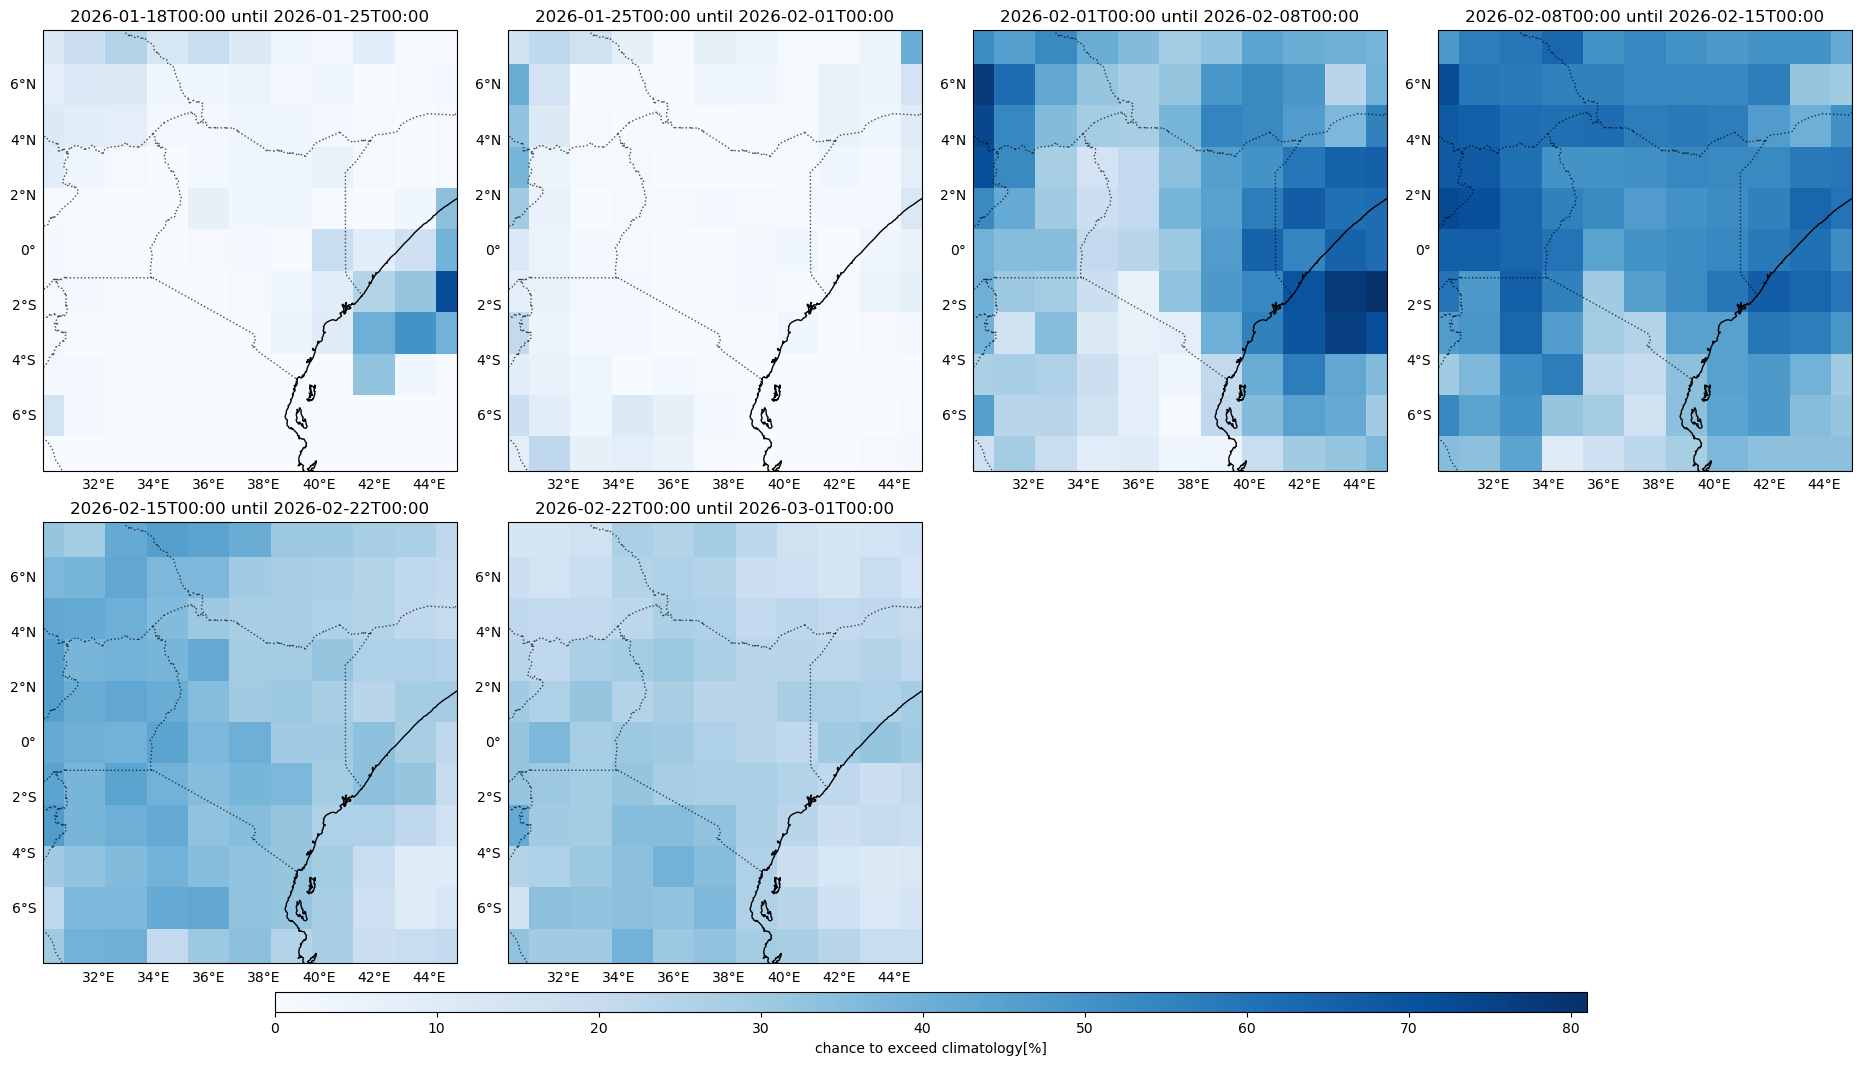

In [8]:
chance_to_exceed=gef.chance_to_exceed_mclimate(weekly_all_vars,quantile=75,m_climate=m_climate)
gef.panel_plot_variable(chance_to_exceed,'tp',chance_to_exceed.step.values,cmap='Blues',fontsize=16)

## Plot anomaly of the ensemble mean from quantile of the model climatology

C:\Users\alecj\Bureaublad\HIWI\namibia_sideproject\get_ECMWF_functions.py:931: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  anom_clim=xr.concat(hold,dim='step')


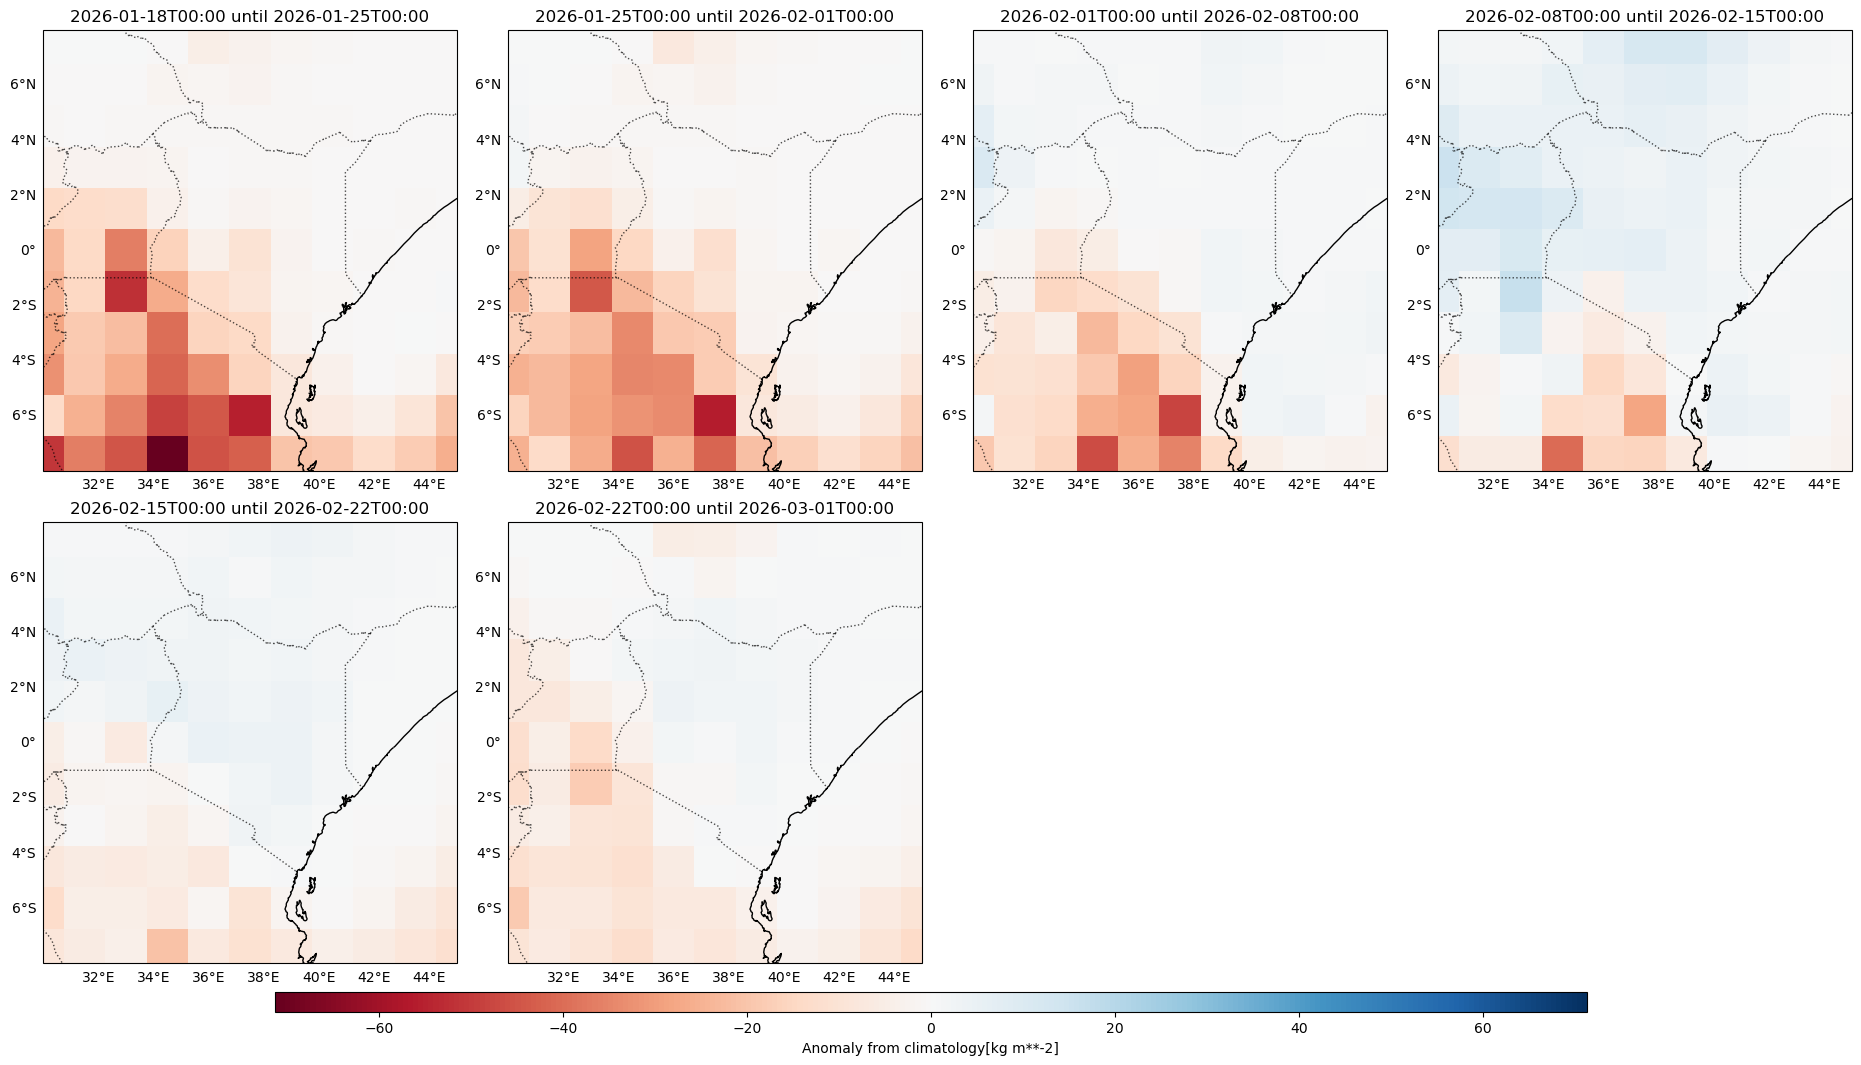

In [13]:
anom_clim=gef.anomaly_from_mclimate(weekly_all_vars,quantile=75,m_climate=m_climate)
gef.panel_plot_variable(anom_clim,'tp',anom_clim.step.values,cmap='RdBu',fontsize=16)

## Plot chance of forecast being in a tercile catagory of the model climatology

C:\Users\alecj\Bureaublad\HIWI\namibia_sideproject\get_ECMWF_functions.py:970: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  tercile_clim=xr.concat(hold,dim='step')


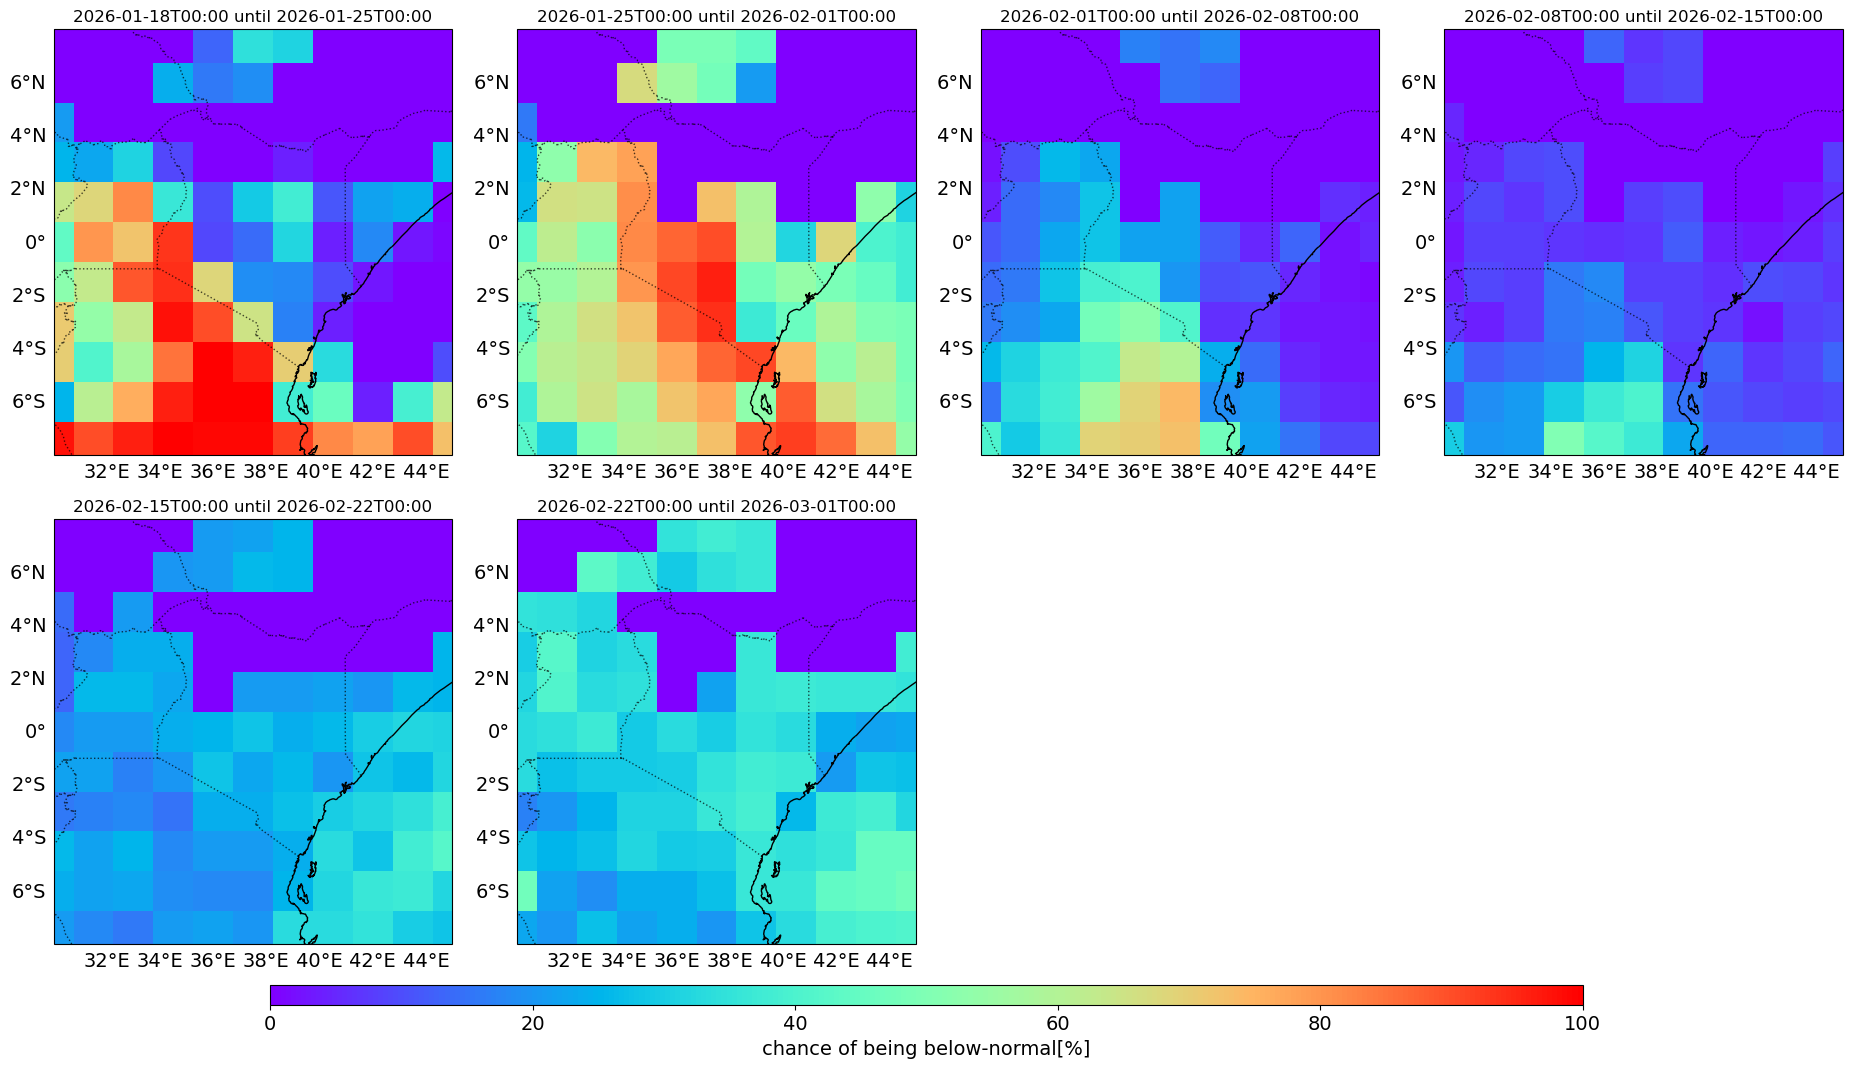

In [15]:
fontsize=14
plt.rcParams.update({'font.size': fontsize})
tercile_clim=gef.tercile_from_mclimate(weekly_all_vars,'tp',category_choice='below-normal',m_climate=m_climate)
gef.panel_plot_variable(tercile_clim,'tp',tercile_clim.step.values,cmap='rainbow')

# Meteogram 
boxes show the min,10th,25th,median,75th,90th & max for the data.

shading shows from 10th to 25h, 25th to 75th & 75th to 90th of the climatology, gray line in middle of shading is the median 


<Axes: title={'center': 'Meteogram: Forecast vs Climatology\nLat: -1.50°, Lon: 36.00°'}, xlabel='Forecast Time Step', ylabel='Precipitation (mm/day)'>

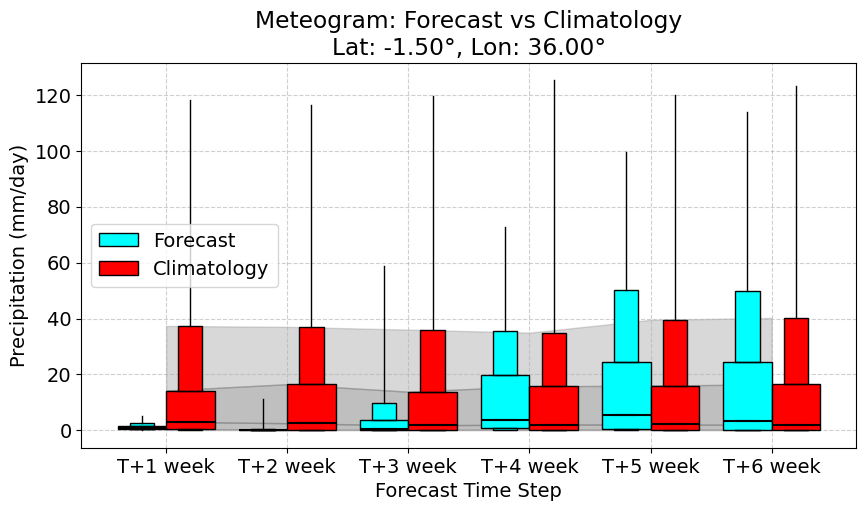

In [66]:
meteogram_double(weekly_all_vars,m_climate,lat=-1,lon=36)

### Plot a windrose for a gridbox

make a windrose for each week for a certain lat lon combination, or select a city like shown below

In [ ]:
lat=-22
lon=13
gef.make_windroses(ds_hourly,lat,lon,10,len(np.atleast_1d(weekly_all_vars.step.values)))

In [28]:
import os
import json
from datetime import datetime, timedelta
from ecmwfapi import ECMWFDataServer

# ---------------------------
# Compute the date two days earlier
# ---------------------------
today = datetime.today()
two_days_earlier = today - timedelta(days=2)
date_str = two_days_earlier.strftime("%Y-%m-%d")
print(f"Downloading data for: {date_str}")

# # ---------------------------
# # Set up ECMWF API credentials from environment variables
# # ---------------------------
# api_config = {
#     "url": os.environ["ECMWF_API_URL"],
#     "key": os.environ["ECMWF_API_KEY"],
#     "email": os.environ["ECMWF_API_EMAIL"]
# }

# # Write credentials to a temporary JSON file
# file_path = "ecmwf_api_key.json"
# with open(file_path, "w") as f:
#     json.dump(api_config, f)

# os.environ["ECMWF_API_RC_FILE"] = file_path

# ---------------------------
# Initialize ECMWF server
# ---------------------------
server = ECMWFDataServer()

# ---------------------------
# Retrieve S2S data
# ---------------------------


target_file = f"s2s.grib"

server.retrieve({
    "class": "s2",
    "dataset": "s2s",
    "date": date_str,
    "expver": "prod",
    "levtype": "sfc",
    "model": "glob",
    "number": "1/to/100",
    "origin": "ecmf",
    "param": "228228",
    "step": "0/168/240/336/480/504/672/720/840/960/1008",
    "stream": "enfo",
    "time": "00:00:00",
    "type": "pf",
    "area": "23/-20/-37/59",
    "target": target_file
})

print(f"Downloaded {target_file} successfully!")



2026-02-10 12:08:51 ECMWF API python library 1.6.3
2026-02-10 12:08:51 ECMWF API at https://api.ecmwf.int/v1
2026-02-10 12:08:51 Welcome Alexander Jong
2026-02-10 12:08:52 In case of problems, please check https://confluence.ecmwf.int/display/WEBAPI/Web+API+FAQ or contact servicedesk@ecmwf.int
2026-02-10 12:08:52 ------------ WARNING ------------
2026-02-10 12:08:52 Access to this dataset is transitioning to a new interface, dates to be announced soon
2026-02-10 12:08:52 For more information on how to access this data in the future, visit https://confluence.ecmwf.int/x/-wUiEw
2026-02-10 12:08:52 ---------------------------------
2026-02-10 12:08:52 Request submitted
2026-02-10 12:08:52 Request id: 698b11c496ab24502762e495
2026-02-10 12:08:52 Request is submitted
2026-02-10 12:08:54 Calling 'nice mars /tmp/20260210-1100/55/tmp-_mars-aBOWFi-39a3452858bb987e04bead71be912aba.req'
2026-02-10 12:08:54 Forcing MIR_CACHE_PATH=/data/ec_coeff
2026-02-10 12:08:54 mars - WARN -
2026-02-10 12:08:54

In [30]:
data=xr.open_dataset('s2s.grib',engine='cfgrib')

Ignoring index file 's2s.grib.5b7b6.idx' older than GRIB file
C:\Users\alecj\Anaconda\envs\get_ECWMF\Lib\site-packages\cfgrib\xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode the variable 'step' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


In [64]:
steps=data.step.values*1e-9/3600
steps=steps.astype('int')
dekade = [data.step.values[i] for i in np.where(steps%240==0)[0]]
weekly=[data.step.values[i] for i in np.where(steps%168==0)[0]]

data_weekly=data.sel(step=weekly)
data_dekade=data.sel(step=dekade)

In [69]:
def acum_to_instant(data):
    diff_data = xr.DataArray(
        data.isel(step=slice(1,None)).tp.values - data.isel(step=slice(0,len(data.step)-1)).tp.values,
        coords={'latitude':data.latitude,'longitude':data.longitude,'step': data.step[1:],'time':data.time,'valid_time':data.valid_time[1:]},  # new step coordinate
        dims=data.dims
    ).clip(min=0)
    diff_data=diff_data.to_dataset(name='tp')
    diff_data.tp.attrs=data.tp.attrs
    return diff_data
    
data_weekly=acum_to_instant(data_weekly)
data_dekade=acum_to_instant(data_dekade)

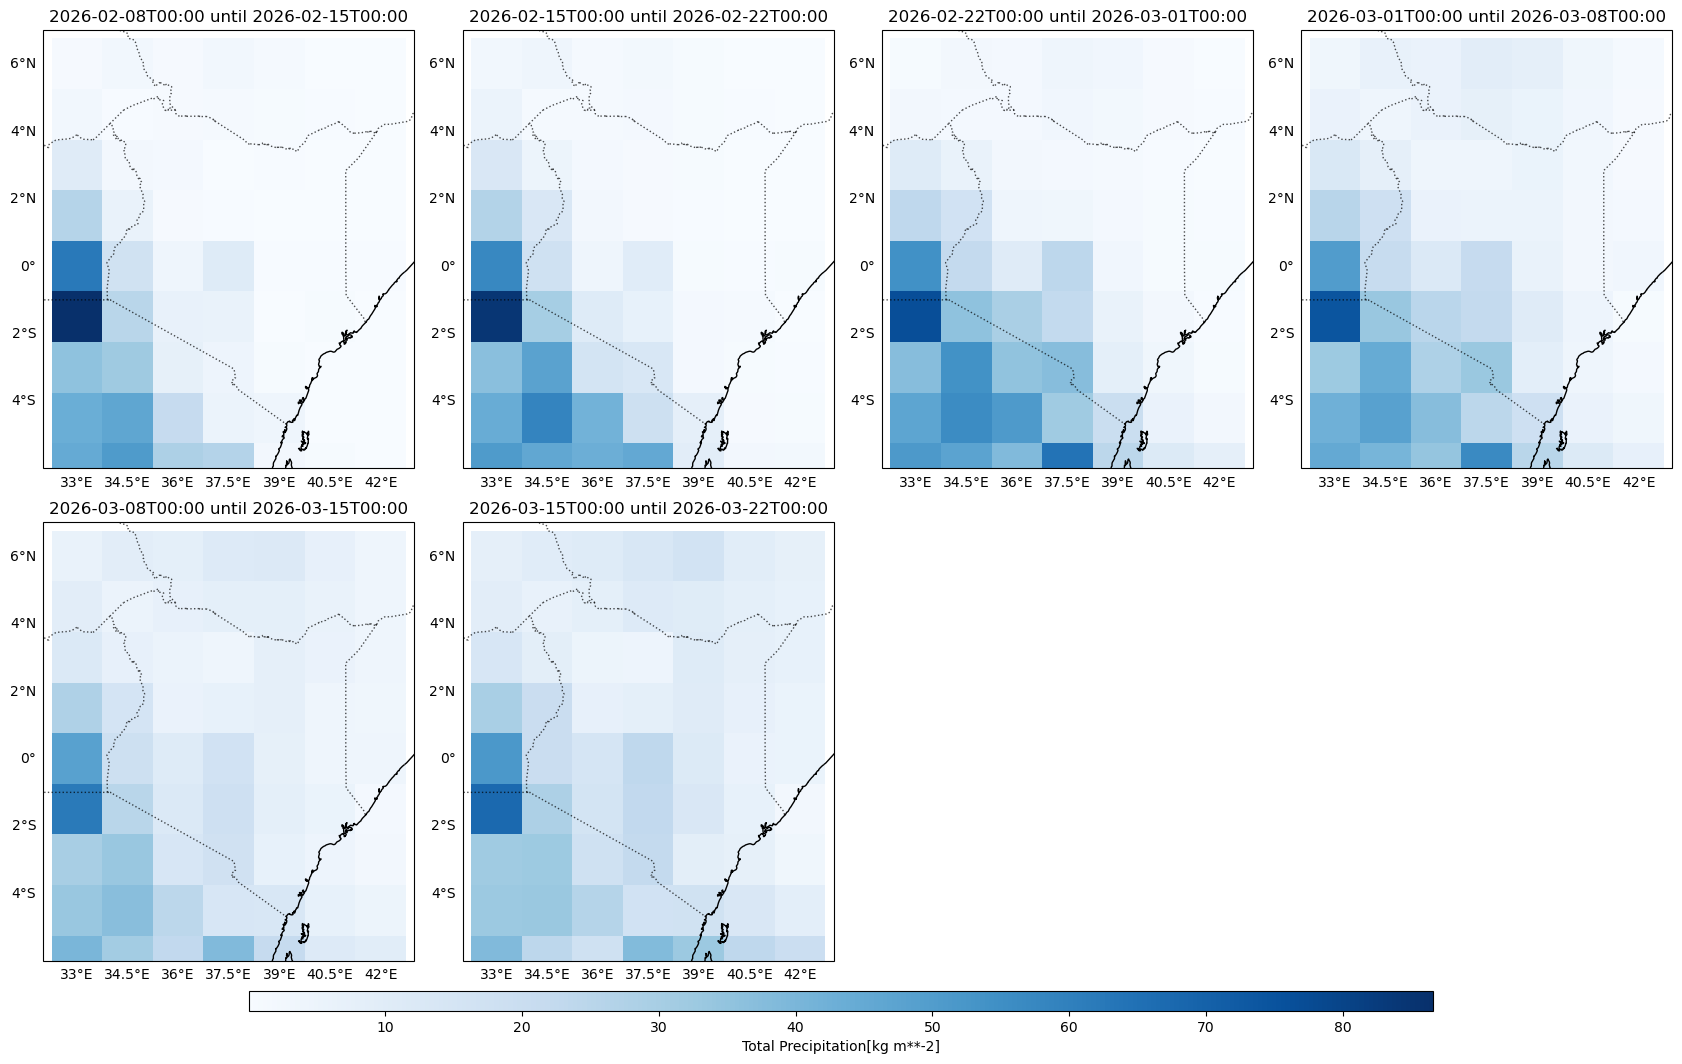

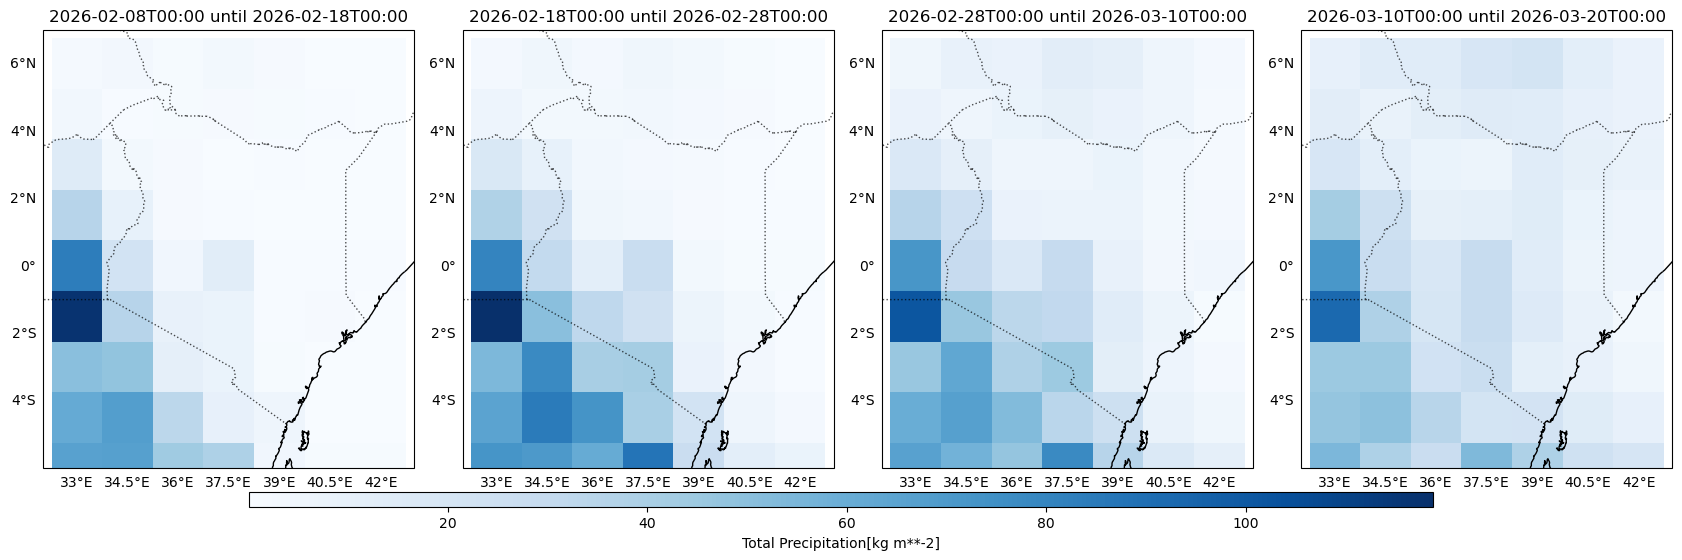

In [73]:
major_cities = {
    "Namibia": [(-22.5594, 17.0832), (-17.9333, 19.7667)],         # Windhoek, Rundu :contentReference[oaicite:0]{index=0}
    "Botswana": [(-24.6545, 25.9086), (-21.1700, 27.5000)],       # Gaborone, Francistown :contentReference[oaicite:1]{index=1}
    "Kenya": [(-1.28333, 36.8167), (-4.0547, 39.6636)],            # Nairobi, Mombasa :contentReference[oaicite:2]{index=2}
    "Zambia": [(-15.4067, 28.2871), (-12.80243, 28.21323)],        # Lusaka, Kitwe :contentReference[oaicite:3]{index=3}
    "Madagascar": [(-18.9137, 47.5361), (-18.1500, 49.4000)]       # Antananarivo, Toamasina  :contentReference[oaicite:4]{index=4}
}

bboxes = {
    "Namibia": {"lat1": -15, "lon1": 10, "lat2": -31, "lon2": 27},
    "Botswana": {"lat1": -15, "lon1": 18, "lat2": -28, "lon2": 31},
    "Kenya": {"lat1": 7, "lon1": 32, "lat2": -6, "lon2": 43},
    "Zambia": {"lat1": -6, "lon1": 20, "lat2": -20, "lon2": 35},
    "Madagascar": {"lat1": -10, "lon1": 42, "lat2": -27, "lon2": 52}
}

country='Kenya'

gef.lat1=bboxes[country]['lat1']
gef.lat2=bboxes[country]['lat2']
gef.lon1=bboxes[country]['lon1']
gef.lon2=bboxes[country]['lon2']

ds_to_plot=data_weekly.sel(longitude=slice(bboxes[country]['lon1'],bboxes[country]['lon2']),latitude=slice(bboxes[country]['lat1'],bboxes[country]['lat2']))
fig=gef.panel_plot_variable(ds_to_plot,variable='tp',forecast_timestep=ds_to_plot.step.values,cmap='Blues',fontsize=15)

ds_to_plot=data_dekade.sel(longitude=slice(bboxes[country]['lon1'],bboxes[country]['lon2']),latitude=slice(bboxes[country]['lat1'],bboxes[country]['lat2']))
fig=gef.panel_plot_variable(ds_to_plot,variable='tp',forecast_timestep=ds_to_plot.step.values,cmap='Blues',fontsize=15)

In [ ]:
import os
import re
from datetime import date, timedelta, datetime
import numpy as np

HOME=os.getcwd()

folder_path = f'{HOME}/m-climate/'
    
# List all files
files = os.listdir(folder_path)

# Define a regex pattern to extract dates (assuming 'yiping_cd_YYYY-MM-DD.nc' format)
pattern = re.compile(r"yiping_cd_(\d{4})-(\d{2})-(\d{2})\.nc")

# Extract month and day, ignoring year
file_dates = []
file_list = []

for file in files:
    match = pattern.search(file)
    if match:
        month, day = int(match.group(2)), int(match.group(3))
        # Normalize all dates to the year 2000
        date_obj = datetime(2000, month, day)
        file_dates.append(date_obj)
        file_list.append(file)  # Keep track of valid files

# Convert file_dates to NumPy datetime64 for easier comparison
file_dates_np = np.array(file_dates, dtype="datetime64")

today = datetime.today()
two_days_earlier = today - timedelta(days=2)

# Specify the target date (only considering month and day)
target_date =two_days_earlier # Example target date
target_date_md = target_date_md = datetime(2000, target_date.month, target_date.day)

# Find the index of the closest date
closest_index = np.argmin(np.abs(file_dates_np - np.datetime64(target_date_md)))

# Get the closest file
closest_file = file_list[closest_index]

print(f"Model climatology starting on: {closest_file[10:20]}")

#open climatology
path=f'{HOME}/m-climate/'
file= closest_file